# Evaluación Parcial N°3 - Deep Learning

## Notebook 1: Clasificación de sentimientos con LSTM

En este notebook se desarrolla un modelo recurrente basado en LSTM para clasificar reseñas de películas como positivas o negativas.

La tarea corresponde a un problema de Procesamiento de Lenguaje Natural, donde el texto de cada reseña será transformado en secuencias numéricas mediante tokenización y padding. Posteriormente, estas secuencias serán utilizadas para entrenar una red neuronal recurrente.

El objetivo es evaluar el desempeño del modelo utilizando métricas de clasificación como accuracy, precision, recall y F1-score.

# Librerias


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Dropout

# Carga del dataset

In [30]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Exploración inicial del dataset

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [32]:
df.shape

(50000, 2)

In [33]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [34]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

El dataset contiene 50.000 reseñas y dos columnas principales: `review`, que contiene el texto de la reseña, y `sentiment`, que contiene la etiqueta asociada. No existen valores nulos y las clases están balanceadas, con 25.000 reseñas positivas y 25.000 reseñas negativas.

# Visualización de la distribución de clases

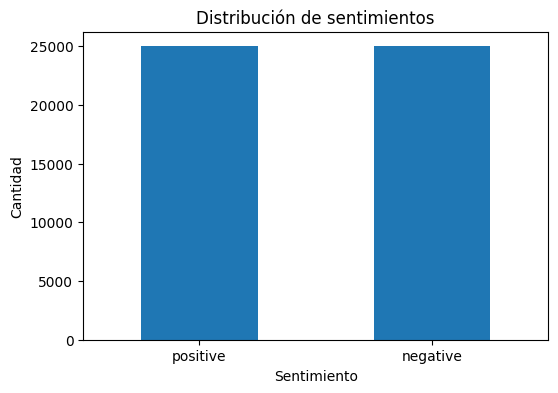

In [38]:
df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

La distribución de clases es equilibrada. Por otro lado se analiza la longitud de las reseñas para decidir posteriormente un tamaño máximo de secuencia durante el proceso de padding.

In [39]:
df['review'].str.len().describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64

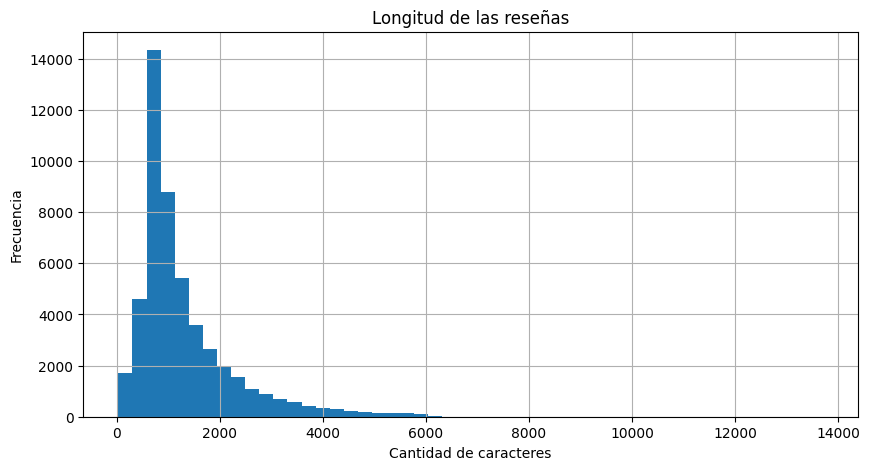

In [40]:
plt.figure(figsize=(10,5))

df['review'].str.len().hist(bins=50)

plt.title('Longitud de las reseñas')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')

plt.show()

Las reseñas presentan longitudes variables. La mayoría se concentra en textos de longitud media, aunque existen algunas reseñas mucho más extensas. Por esta razón, se aplicará padding para que todas las secuencias tengan el mismo largo antes de ingresar al modelo LSTM.

## Preprocesamiento del texto

Antes de entrenar la red neuronal transformaremos los datos a un formato numérico.

- negative → 0
- positive → 1

Posteriormente, las reseñas serán tokenizadas y transformadas en secuencias de números para que puedan ser procesadas por la red LSTM.

In [41]:
df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
# Separación de variables

X = df['review']
y = df['sentiment']

In [ ]:
# Division del conjunto de datos

# Se utiliza la opción `stratify` para mantener la misma proporción de clases en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [44]:
print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (40000,)
Prueba: (10000,)


# Tokenizacion del texto


Se utilizarán:

- Máximo de palabras del vocabulario: 10.000.
- Longitud máxima de secuencia: 200 palabras.

In [45]:
MAX_WORDS = 10000
MAX_LEN = 200

In [46]:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    lower=True
)

tokenizer.fit_on_texts(X_train)

Una vez construido el vocabulario, las reseñas se transforman en secuencias de números enteros.

In [47]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [48]:
print(X_train_seq[0][:30])

[10, 1054, 11, 119, 1505, 457, 31, 1608, 142, 8, 4300, 38, 10, 13, 30, 3, 8743, 1671, 5, 63, 105, 158, 671, 868, 867, 97, 1, 1671, 13, 2836]


Las secuencias obtenidas poseen longitudes distintas, por lo que se aplicará padding para que todas tengan el mismo tamaño.

In [49]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)

In [50]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


Después del padding, todas las reseñas tienen la misma longitud de 200 palabras, lo que permite ingresarlas correctamente al modelo LSTM.

## Construcción del modelo LSTM

Se implementará una arquitectura basada en:

- Embedding.
- SpatialDropout1D.
- LSTM.
- Dropout.
- Capa de salida con activación Sigmoid.

Esta arquitectura es adecuada para problemas de clasificación binaria y permite capturar dependencias temporales presentes en el texto.